In [1]:
%%bash
#!/bin/bash
hostname



tri0018


In [2]:
%%bash
echo -e "\nCGroup Enforcement:"
if [ -f /sys/fs/cgroup/memory/memory.limit_in_bytes ]; then
    MEM_BYTES=$(cat /sys/fs/cgroup/memory/memory.limit_in_bytes)
    # Convert to GB (using 1024^3)
    echo "Memory Limit (CGroup): $(awk "BEGIN {print $MEM_BYTES/1024/1024/1024}") GB"
elif [ -f /sys/fs/cgroup/memory.max ]; then
    # CGroup v2
    MEM_MAX=$(cat /sys/fs/cgroup/memory.max)
    echo "Memory Limit (CGroup v2): $MEM_MAX"
fi

# 4. If using Slurm (common on HPC)
if command -v squeue >/dev/null 2>&1; then
    echo -e "\nSlurm Job Info:"
    squeue --me
fi


CGroup Enforcement:



Slurm Job Info:


          JOBID            USER        ACCOUNT           NAME  ST  TIME_LEFT     PARTITION NODES   C

PUS NODELIST (REASON)
        1293824        liuhon33    def-dfelsky jupyter_notebo   R    5:06:38  

     compute     1    192 tri0580 (None)
        1293942        liuhon33    def-dfelsky notebook_sub

mi   R   11:59:51       compute     1    192 tri0018 (None)


In [3]:
import os
os.getcwd()

'/scratch/liuhon33/parallel/AGPMicrobiomeHostPredictions'

In [4]:
# 0. Import Libraries 
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

from tqdm.notebook import tqdm # for terminal progress tracking
import os
import time # used to time each cross validation
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json
from pathlib import Path
from matplotlib.backends.backend_pdf import PdfPages

# 1. Configuration
otu_file_path = "./Data/Cleaned_data/AGP_Otu_Data.csv"
metadata_file_path = "./Data/Cleaned_data/processed_metadata.csv"
metadata_index_col = 'sample_name'
otu_index_col = 0

outer_cv_splits = 10
inner_cv_splits = 5
random_state_cv = 42 # AI loves this random seed for some reason
abundance_threshold = 0.0001
n_cpu = -1 # depends of the cpu I requested

n_pcs_to_predict = 150     # How many PCs to use as targets for the RF models
n_pcs_to_explore = 150    # How many PCs to calculate for the exploratory plots
n_pcs_to_implement = 10

param_grid = {
    'rf__n_estimators': [100, 200, 300],
    'rf__max_features': ['sqrt', 'log2'],
    'rf__min_samples_leaf': [5, 10, 20],
    'rf__max_depth': [None, 10, 20]
}

output_dir = "./hongrui_result/RF_on_PCA_Results/"
os.makedirs(output_dir, exist_ok=True)
# save trained objects
model_dir = "./RF_PCA_Trained_Models/"
os.makedirs(model_dir, exist_ok=True)

# --- HARD-CODE: columns to EXCLUDE from training (e.g., not available in UKB) ---
EXCLUDE_METADATA_COLS = [
    "cat",
    "dog",
    "multivitamin",
    "other_supplement_frequency",
    "cosmetics_frequency",
    "fermented_plant_frequency",
    "homecooked_meals_frequency",
    "meat_eggs_frequency",
    "sugary_sweets_frequency",
    "vivid_dreams",
    "sugar_sweetened_drink_frequency",
    #"free_sugar_scaled_0_5",
    "artificial_sweeteners",
    #"one_liter_of_water_a_day_frequency",
    "olive_oil",
    "prepared_meals_frequency",
    "ready_to_eat_meals_frequency",
    #"probiotic_frequency",
    "whole_eggs",
    "frozen_dessert_frequency",
]

In [5]:
# 2. Load and Prepare Data
print("--- Loading data ---")
metadata_df = pd.read_csv(metadata_file_path, index_col=metadata_index_col)
otu_df = pd.read_csv(otu_file_path, index_col=otu_index_col)

# 2a. Convert coded "5 = unknown/unspecified" to missing in numeric metadata columns
numeric_metadata_cols = metadata_df.select_dtypes(include=[np.number]).columns
metadata_df[numeric_metadata_cols] = metadata_df[numeric_metadata_cols].replace(5, np.nan)

print("Converted coded value 5 to NaN in numeric metadata columns.")
print(f"Total numeric metadata columns processed: {len(numeric_metadata_cols)}")

common_samples = metadata_df.index.intersection(otu_df.index)
metadata_df = metadata_df.loc[common_samples]
otu_df = otu_df.loc[common_samples]
print(f"Data aligned. Found {len(common_samples)} common samples.")
print(f"Initial number of OTUs: {otu_df.shape[1]}")

# 2.5 rename OTU columns using taxa map (RENAME ONLY; no collapse)
taxa_map_path = Path("./Data/Raw_Data/taxa_md5.xls")

taxa_df = pd.read_csv(
    taxa_map_path,
    sep="\t",
    header=0,
    index_col=0,
    engine="python"
)

# IMPORTANT: clean taxa_df index to match OTU md5 strings
taxa_df.index = taxa_df.index.astype(str).str.strip()

taxa_df["Family"] = taxa_df["Family"].fillna("UnclassifiedFamily").astype(str).str.strip()
taxa_df["Genus"]  = taxa_df["Genus"].fillna("UnclassifiedGenus").astype(str).str.strip()
taxa_df["Family_Genus"] = taxa_df["Family"] + "_" + taxa_df["Genus"]

mapper = taxa_df["Family_Genus"].to_dict()

md5_prefix_len = 8

def make_unique(names):
    counts = {}
    out = []
    for n in names:
        k = counts.get(n, 0) + 1
        counts[n] = k
        out.append(n if k == 1 else f"{n}__{k}")
    return out

# Use the ORIGINAL md5 columns (before any renaming)
otu_md5 = otu_df.columns.astype(str).str.strip()

# Build labels: Family_Genus__<md5prefix>, fallback Unmapped__<md5prefix>
new_cols = [f"{mapper.get(m, 'Unmapped')}__{m[:md5_prefix_len]}" for m in otu_md5]

otu_df = otu_df.copy()
otu_df.columns = make_unique(new_cols)

n_mapped = sum(m in mapper for m in otu_md5)
print(f"[taxa-map] Mapped {n_mapped}/{len(otu_md5)} OTUs (rename-only; no collapse).")
print("Example renamed columns:", list(otu_df.columns[:5]))
print("Any duplicates after rename?", pd.Index(otu_df.columns).duplicated().any())
# Filter OTU Table
otu_rel_abund = otu_df.apply(lambda x: x / x.sum(), axis=1)
mean_rel_abund = otu_rel_abund.mean(axis=0)
otus_to_keep = mean_rel_abund[mean_rel_abund > abundance_threshold].index
otu_df_filtered = otu_df[otus_to_keep]
print(f"Number of OTUs after filtering: {otu_df_filtered.shape[1]}")

# Log Transform OTU Data (Y-base) # will edit later for the CLR transformation
otu_df_log_transformed = np.log1p(otu_df_filtered)
print("Applied log(x+1) transformation to OTU counts.")

--- Loading data ---


Converted coded value 5 to NaN in numeric metadata columns.
Total numeric metadata columns processed: 44
Data aligned. Found 9559 common samples.
Initial number of OTUs: 4460


[taxa-map] Mapped 4460/4460 OTUs (rename-only; no collapse).
Example renamed columns: ['Bacteroidaceae_Bacteroides__ef63210b', 'Bacteroidaceae_Bacteroides__fee9d92e', 'Ruminococcaceae_Faecalibacterium__26beb329', 'Bacteroidaceae_Bacteroides__48645283', 'Ruminococcaceae_Faecalibacterium__6bfe71f5']
Any duplicates after rename? False


Number of OTUs after filtering: 819
Applied log(x+1) transformation to OTU counts.


In [6]:
# Prepare metadata predictors (X) (NO global imputation / NO global scaling) Usually Random Forest do not need for scaling
numeric_cols = metadata_df.select_dtypes(include=np.number).columns

# Drop excluded columns if they exist
excluded_present = [c for c in EXCLUDE_METADATA_COLS if c in numeric_cols]
if excluded_present:
    print(f"Dropping {len(excluded_present)} hard-coded excluded predictors: {excluded_present}")

numeric_cols = [c for c in numeric_cols if c not in EXCLUDE_METADATA_COLS]

X_metadata = metadata_df[numeric_cols]
print(f"Using {X_metadata.shape[1]} numeric metadata features as predictors (after exclusions).")

# Force age_corrected to numeric so it gets included in numeric_cols
# metadata_df["age_corrected"] = pd.to_numeric(metadata_df["age_corrected"], errors="coerce")

#numeric_cols = metadata_df.select_dtypes(include=np.number).columns
#X_metadata = metadata_df[numeric_cols]
#print(f"Using {X_metadata.shape[1]} numeric metadata features as predictors.")

#print("\n--- Predictor columns used (X_metadata) ---")
#print(list(X_metadata.columns))
#print(f"Total predictors: {X_metadata.shape[1]}")
#print(f"Using {X_metadata.shape[1]} numeric metadata features as predictors.")

print("\n--- METADATA PREDICTORS (X) ---")
print(f"Total Predictors: {X_metadata.shape[1]}")
for i, col in enumerate(X_metadata.columns, 1):
    print(f"{i}. {col}")
print("-------------------------------\n")

# --- 3. Exploratory PCA on Microbiome Data (KEEP AS-IS for now) ---
# NOTE: This exploratory PCA is fine for plots, but it is NOT used for model targets anymore.
print(f"\n--- 3. Performing EXPLORATORY PCA on {otu_df_filtered.shape[1]} log-transformed OTUs ---")
scaler_otu = StandardScaler()
otu_scaled = scaler_otu.fit_transform(otu_df_log_transformed)

pca_otu_full = PCA(n_components=None)
pca_otu_full.fit(otu_scaled)

all_otu_explained_variance = pca_otu_full.explained_variance_ratio_
cumulative_variance = np.cumsum(all_otu_explained_variance)
components_for_50_percent = np.argmax(cumulative_variance >= 0.50) + 1

print("\n--- OTU PCA Variance Analysis ---")
print(f"** Components needed to explain 50% of variance: {components_for_50_percent} **")
print("---------------------------------")

otu_explained_variance_explore = all_otu_explained_variance[:n_pcs_to_explore]
pca_otu_scores_full = pca_otu_full.transform(otu_scaled)
pca_otu_scores_explore = pca_otu_scores_full[:, :n_pcs_to_explore]
pca_otu_loadings_explore = pca_otu_full.components_[:n_pcs_to_explore, :]

print("Exploratory OTU PCA complete.")
print(f"Variance explained by first {n_pcs_to_explore} OTU components:")
for i, var in enumerate(otu_explained_variance_explore):
    print(f"  PC{i+1}: {var*100:.2f}%")

Dropping 17 hard-coded excluded predictors: ['cat', 'dog', 'multivitamin', 'other_supplement_frequency', 'cosmetics_frequency', 'fermented_plant_frequency', 'homecooked_meals_frequency', 'meat_eggs_frequency', 'sugary_sweets_frequency', 'vivid_dreams', 'sugar_sweetened_drink_frequency', 'artificial_sweeteners', 'olive_oil', 'prepared_meals_frequency', 'ready_to_eat_meals_frequency', 'whole_eggs', 'frozen_dessert_frequency']
Using 27 numeric metadata features as predictors (after exclusions).

--- METADATA PREDICTORS (X) ---
Total Predictors: 27
1. alcohol_consumption
2. appendix_removed
3. lactose
4. alcohol_frequency
5. exercise_frequency
6. flossing_frequency
7. fruit_frequency
8. high_fat_red_meat_frequency
9. milk_cheese_frequency
10. milk_substitute_frequency
11. one_liter_of_water_a_day_frequency
12. poultry_frequency
13. probiotic_frequency
14. red_meat_frequency
15. salted_snacks_frequency
16. seafood_frequency
17. smoking_frequency
18. teethbrushing_frequency
19. vegetable_fre


--- OTU PCA Variance Analysis ---
** Components needed to explain 50% of variance: 178 **
---------------------------------
Exploratory OTU PCA complete.
Variance explained by first 150 OTU components:
  PC1: 3.71%
  PC2: 2.13%
  PC3: 1.77%
  PC4: 1.43%
  PC5: 1.10%
  PC6: 1.04%
  PC7: 0.94%
  PC8: 0.82%
  PC9: 0.78%
  PC10: 0.75%
  PC11: 0.69%
  PC12: 0.62%
  PC13: 0.58%
  PC14: 0.56%
  PC15: 0.50%
  PC16: 0.48%
  PC17: 0.47%
  PC18: 0.46%
  PC19: 0.46%
  PC20: 0.43%
  PC21: 0.42%
  PC22: 0.42%
  PC23: 0.41%
  PC24: 0.38%
  PC25: 0.37%
  PC26: 0.36%
  PC27: 0.35%
  PC28: 0.34%
  PC29: 0.32%
  PC30: 0.31%
  PC31: 0.31%
  PC32: 0.30%
  PC33: 0.30%
  PC34: 0.29%
  PC35: 0.28%
  PC36: 0.28%
  PC37: 0.27%
  PC38: 0.27%
  PC39: 0.26%
  PC40: 0.26%
  PC41: 0.25%
  PC42: 0.25%
  PC43: 0.25%
  PC44: 0.24%
  PC45: 0.24%
  PC46: 0.24%
  PC47: 0.24%
  PC48: 0.24%
  PC49: 0.23%
  PC50: 0.23%
  PC51: 0.22%
  PC52: 0.22%
  PC53: 0.22%
  PC54: 0.22%
  PC55: 0.21%
  PC56: 0.21%
  PC57: 0.21%
  PC58: 

In [7]:
# if "age_corrected" in metadata_df.columns:
    # print("dtype:", metadata_df["age_corrected"].dtype)
    # print(metadata_df["age_corrected"].head(20))
    # print("n_unique:", metadata_df["age_corrected"].nunique(dropna=False))

In [8]:
# 4. Generate Exploratory OTU PCA Plots (unchanged)
print("\n--- 4. Generating Exploratory OTU PCA Plots ---")
plt.figure(figsize=(8, 5))
sns.barplot(x=[f'PC{i+1}' for i in range(n_pcs_to_explore)],
            y=otu_explained_variance_explore * 100,
            color="steelblue")
plt.title('Scree Plot - Variance Explained by OTU PCs')
plt.ylabel('Percent Variance Explained')
plt.xlabel('Principal Component')
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "otu_pca_scree_plot.pdf"))
print(f"OTU Scree plot saved to '{output_dir}otu_pca_scree_plot.pdf'")
plt.close()

pca_otu_scores_df = pd.DataFrame(pca_otu_scores_explore, columns=[f'PC{i+1}' for i in range(n_pcs_to_explore)])
plt.figure(figsize=(8, 7))
sns.scatterplot(data=pca_otu_scores_df, x='PC1', y='PC2', alpha=0.3)
plt.title('OTU PCA Scores Plot (Samples in PC Space)')
plt.xlabel(f'PC1 ({otu_explained_variance_explore[0]*100:.2f}%)')
plt.ylabel(f'PC2 ({otu_explained_variance_explore[1]*100:.2f}%)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "otu_pca_scores_plot.pdf"))
print(f"OTU Scores plot saved to '{output_dir}otu_pca_scores_plot.pdf'")
plt.close()

# --- NEW: multi-page PDF of loadings for PC1..PC5 ---
top_k = 10  # top_k positive + top_k negative loadings shown per PC
pcs_to_plot = min(10, n_pcs_to_explore, pca_otu_loadings_explore.shape[0])

pdf_path = os.path.join(output_dir, f"otu_pca_pc1_pc{pcs_to_plot}_loadings.pdf")

with PdfPages(pdf_path) as pdf:
    for pc_idx in range(pcs_to_plot):
        pc_num = pc_idx + 1

        loadings = pd.Series(
            pca_otu_loadings_explore[pc_idx, :],
            index=otu_df_filtered.columns
        )

        top = pd.concat([loadings.nlargest(top_k), loadings.nsmallest(top_k)]).sort_values()

        fig, ax = plt.subplots(figsize=(10, 8))
        ax.barh(top.index, top.values)          # pure matplotlib
        ax.axvline(0, linewidth=1)              # zero line
        ax.set_xlabel("Loading Value")
        ax.set_ylabel("OTU Identifier")

        var_pct = otu_explained_variance_explore[pc_idx] * 100
        ax.set_title(f"OTU Loadings for PC{pc_num} (Top ±{top_k}; {var_pct:.2f}% variance)")

        fig.tight_layout()
        pdf.savefig(fig)
        plt.close(fig)

print(f"Multi-page OTU loadings PDF saved to: {pdf_path}")


--- 4. Generating Exploratory OTU PCA Plots ---


OTU Scree plot saved to './hongrui_result/RF_on_PCA_Results/otu_pca_scree_plot.pdf'
OTU Scores plot saved to './hongrui_result/RF_on_PCA_Results/otu_pca_scores_plot.pdf'


Multi-page OTU loadings PDF saved to: ./hongrui_result/RF_on_PCA_Results/otu_pca_pc1_pc10_loadings.pdf


In [9]:
# 5. Run Nested Cross-Validation for each PC (FIXED: PCA inside outer loop; imputation in pipeline; no scaling for RF) 
print(f"\n--- 5. Running {outer_cv_splits}-Fold Nested CV for {n_pcs_to_predict} Microbiome PCs ---")
print("Key fixes applied: PCA+OTU scaling fit on outer-train only; metadata imputation inside pipeline; no metadata scaling for RF.")

nested_cv_results = {}

outer_cv = KFold(n_splits=outer_cv_splits, shuffle=True, random_state=random_state_cv)

# Pre-build the RF pipeline: impute metadata -> RF
rf_pipe = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('rf', RandomForestRegressor(random_state=random_state_cv))
])

# Inner CV splitter # use KFold for now, assume one individual only has one sample
inner_cv = KFold(n_splits=inner_cv_splits, shuffle=True, random_state=random_state_cv)

# We'll run per-PC, but note: PCs are defined per-outer-fold now. (no more leakage mistakes as Dr. Campbell suggest)
for pc_idx in range(n_pcs_to_predict):
    pc_name = f'PC{pc_idx+1}'
    print(f"\n... Processing {pc_name} ...")
    start_time = time.time()

    outer_loop_scores = []
    y_true_all_folds = []
    y_pred_all_folds = []

    for fold, (train_idx, test_idx) in enumerate(tqdm(outer_cv.split(X_metadata), total=outer_cv_splits, desc=f"Outer CV for {pc_name}")):
        # Split X
        X_outer_train = X_metadata.iloc[train_idx]
        X_outer_test  = X_metadata.iloc[test_idx]

        # Split OTUs (Y-base) for PCA fitting
        Y_outer_train_base = otu_df_log_transformed.iloc[train_idx]
        Y_outer_test_base  = otu_df_log_transformed.iloc[test_idx]

        # FIT OTU SCALER + PCA ON OUTER-TRAIN ONLY
        otu_scaler_fold = StandardScaler()
        Y_train_scaled = otu_scaler_fold.fit_transform(Y_outer_train_base)
        Y_test_scaled  = otu_scaler_fold.transform(Y_outer_test_base)

        pca_fold = PCA(n_components=max(n_pcs_to_predict, n_pcs_to_explore))
        pca_fold.fit(Y_train_scaled)

        # Transform to PC scores (targets)
        Y_train_pcs = pca_fold.transform(Y_train_scaled)[:, :n_pcs_to_predict]
        Y_test_pcs  = pca_fold.transform(Y_test_scaled)[:, :n_pcs_to_predict]

        y_outer_train = Y_train_pcs[:, pc_idx]
        y_outer_test  = Y_test_pcs[:, pc_idx]

        # --- Inner loop hyperparameter tuning (ONLY on outer-train) ---
        grid_search = GridSearchCV(
            estimator=rf_pipe,
            param_grid=param_grid,
            cv=inner_cv,
            scoring='r2',
            n_jobs=-1,
            verbose=0
        )
        grid_search.fit(X_outer_train, y_outer_train)

        # --- Evaluate on outer test ---
        best_model = grid_search.best_estimator_
        y_pred = best_model.predict(X_outer_test)

        score = r2_score(y_outer_test, y_pred)
        outer_loop_scores.append(score)

        y_true_all_folds.append(y_outer_test)
        y_pred_all_folds.append(y_pred)

    nested_cv_results[pc_name] = {
    'avg_r2': float(np.mean(outer_loop_scores)),
    'std_r2': float(np.std(outer_loop_scores, ddof=1)),
    'fold_r2': [float(s) for s in outer_loop_scores],   # <-- NEW (10 points per PC)
    'y_true': np.concatenate(y_true_all_folds),
    'y_pred': np.concatenate(y_pred_all_folds)
}

    end_time = time.time()
    print(f"  {pc_name} Average R^2: {nested_cv_results[pc_name]['avg_r2']:.4f} +/- {nested_cv_results[pc_name]['std_r2']:.4f} (took {end_time - start_time:.1f} seconds)")


--- 5. Running 10-Fold Nested CV for 150 Microbiome PCs ---
Key fixes applied: PCA+OTU scaling fit on outer-train only; metadata imputation inside pipeline; no metadata scaling for RF.

... Processing PC1 ...


Outer CV for PC1:   0%|          | 0/10 [00:00<?, ?it/s]

  PC1 Average R^2: 0.1392 +/- 0.0199 (took 61.8 seconds)

... Processing PC2 ...


Outer CV for PC2:   0%|          | 0/10 [00:00<?, ?it/s]

  PC2 Average R^2: 0.0349 +/- 0.0127 (took 62.4 seconds)

... Processing PC3 ...


...

  PC148 Average R^2: -0.0037 +/- 0.0048 (took 53.9 seconds)

... Processing PC149 ...


Outer CV for PC149:   0%|          | 0/10 [00:00<?, ?it/s]

  PC149 Average R^2: -0.0039 +/- 0.0070 (took 54.4 seconds)

... Processing PC150 ...


Outer CV for PC150:   0%|          | 0/10 [00:00<?, ?it/s]

  PC150 Average R^2: -0.0009 +/- 0.0070 (took 50.6 seconds)



--- 6a. Generating Ordered PC outer-fold CV R^2 plot (folds + mean) ---


Saved ordered PC outer-fold CV plot to: ./hongrui_result/RF_on_PCA_Results/ordered_pc_outer_fold_cv_r2.pdf


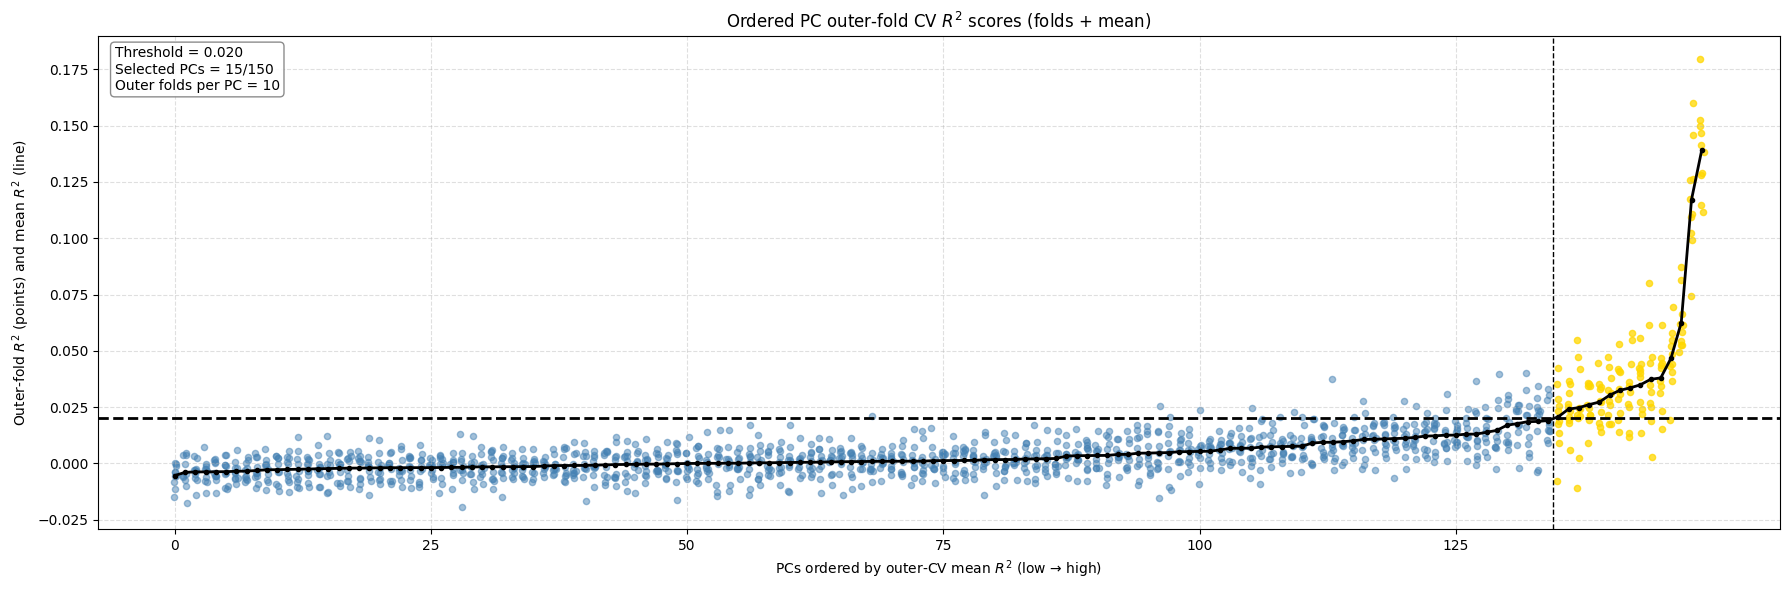


=== Top 15 PCs by mean outer-CV R² ===
pc   mean_r2 sd_r2 
 PC1 0.1392  0.0199
 PC3 0.1171  0.0242
 PC8 0.0626  0.0126
 PC9 0.0467  0.0136
PC25 0.0380  0.0130
 PC4 0.0373  0.0221
 PC2 0.0349  0.0127
PC33 0.0335  0.0155
PC10 0.0325  0.0120
 PC7 0.0303  0.0102
 PC6 0.0272  0.0096
PC23 0.0261  0.0088
PC30 0.0248  0.0197
 PC5 0.0242  0.0090
PC11 0.0207  0.0141


In [10]:
# 6a. Ordered PC outer-fold CV R2 scatter (folds + mean), like OTU plot
print("\n--- 6a. Generating Ordered PC outer-fold CV R^2 plot (folds + mean) ---")

r2_threshold = 0.02
rng = np.random.RandomState(0)

# Sort PCs by mean R2 (low -> high)
pc_order = sorted(nested_cv_results.keys(), key=lambda k: nested_cv_results[k]['avg_r2'])
means = np.array([nested_cv_results[pc]['avg_r2'] for pc in pc_order], dtype=float)

n_total = len(pc_order)
selected_mask = means > r2_threshold
n_selected = int(selected_mask.sum())

# Find where we first cross the threshold in the ordered list
cross_idx = None
idxs = np.where(selected_mask)[0]
if len(idxs) > 0:
    cross_idx = int(idxs[0])

plt.figure(figsize=(18, 6))

x = np.arange(n_total)

# Scatter the fold scores (10 points per PC)
for i, pc in enumerate(pc_order):
    fold_scores = np.array(nested_cv_results[pc]['fold_r2'], dtype=float)
    jitter = rng.uniform(-0.18, 0.18, size=len(fold_scores))

    if nested_cv_results[pc]['avg_r2'] > r2_threshold:
        point_color = 'gold'
        point_alpha = 0.75
    else:
        point_color = 'steelblue'
        point_alpha = 0.5

    plt.scatter(i + jitter, fold_scores,
                alpha=point_alpha, s=20, color=point_color, label=None)

# Mean line
plt.plot(x, means, marker='o', markersize=3, linewidth=2, color='black',
         label='PC mean outer-CV $R^2$')

# Threshold line + optional vertical cutoff guide
plt.axhline(r2_threshold, linestyle='--', linewidth=2, color='black',
            label=f'Threshold = {r2_threshold:.2f}')
if cross_idx is not None:
    plt.axvline(cross_idx - 0.5, linestyle='--', linewidth=1, color='black')

# Cosmetics similar to your OTU figure
plt.title("Ordered PC outer-fold CV $R^2$ scores (folds + mean)")
plt.xlabel("PCs ordered by outer-CV mean $R^2$ (low → high)")
plt.ylabel("Outer-fold $R^2$ (points) and mean $R^2$ (line)")
plt.grid(True, linestyle='--', alpha=0.4)

# Don’t label every PC (too many); show a few ticks
tick_step = 25 if n_total >= 100 else 10
ticks = np.arange(0, n_total, tick_step)
plt.xticks(ticks, ticks)

# Info box
info = (
    f"Threshold = {r2_threshold:.3f}\n"
    f"Selected PCs = {n_selected}/{n_total}\n"
    f"Outer folds per PC = {outer_cv_splits}"
)
plt.text(
    0.01, 0.98, info,
    transform=plt.gca().transAxes,
    va='top', ha='left',
    bbox=dict(boxstyle="round", fc="white", ec="gray", alpha=0.9)
)

plt.tight_layout()
out_path = os.path.join(output_dir, "ordered_pc_outer_fold_cv_r2.pdf")
plt.savefig(out_path)
print(f"Saved ordered PC outer-fold CV plot to: {out_path}")
plt.show()
plt.close()

# Report top 15 PCs by mean outer-CV R² (assumes nested_cv_results exists)

top15_df = (
    pd.DataFrame([
        {
            "pc": pc,
            "mean_r2": float(res.get("avg_r2", float("nan"))),
            "sd_r2": float(res.get("std_r2", float("nan"))),
        }
        for pc, res in nested_cv_results.items()
    ])
    .sort_values("mean_r2", ascending=False)
    .head(15)
    .reset_index(drop=True)
)

print("\n=== Top 15 PCs by mean outer-CV R² ===")
print(top15_df.to_string(index=False, justify="left",
                         formatters={"mean_r2": "{:.4f}".format, "sd_r2": "{:.4f}".format}))


--- 6b. Generating Model Performance Bar Plot (Top 15 PCs) ---
Performance bar plot saved to './hongrui_result/RF_on_PCA_Results/rf_model_performance_bar_plot_top15.pdf'


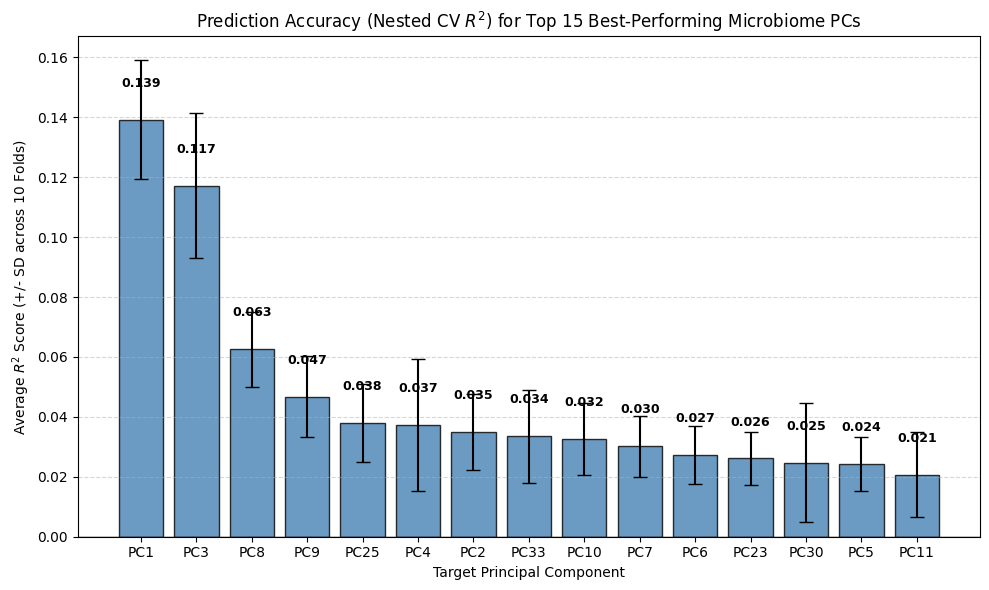


--- 7. Generating Plots for Top 5 Best PCs ---


Prediction scatter plot for rank 1 (PC1) saved to './hongrui_result/RF_on_PCA_Results/top1_prediction_scatter_actual_fit_PC1.pdf'


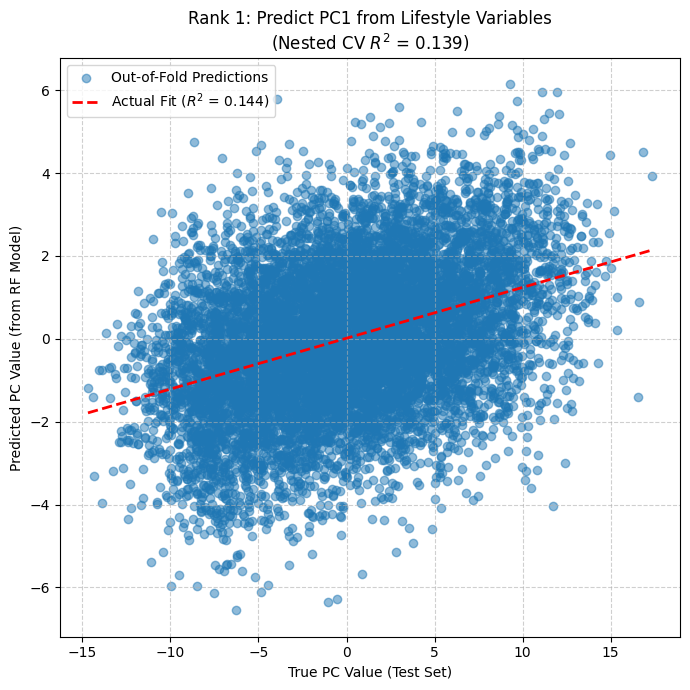

Prediction scatter plot for rank 2 (PC3) saved to './hongrui_result/RF_on_PCA_Results/top2_prediction_scatter_actual_fit_PC3.pdf'


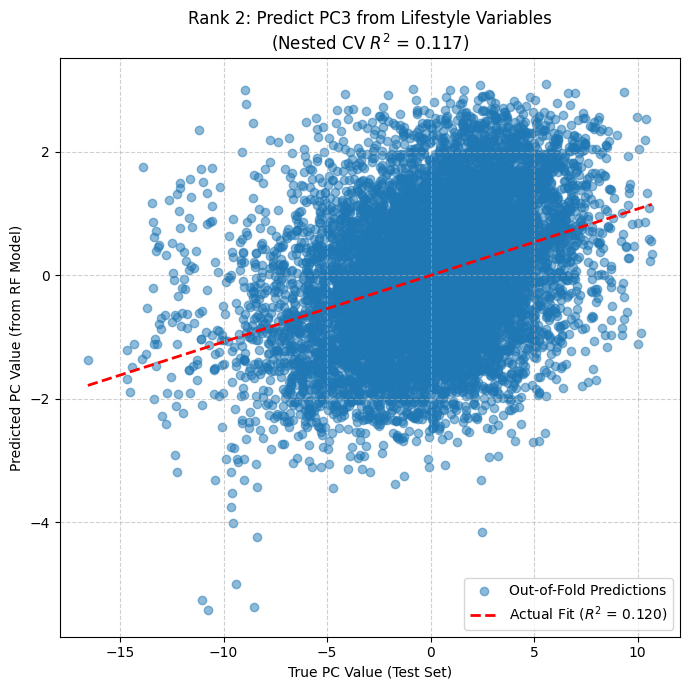

Prediction scatter plot for rank 3 (PC8) saved to './hongrui_result/RF_on_PCA_Results/top3_prediction_scatter_actual_fit_PC8.pdf'


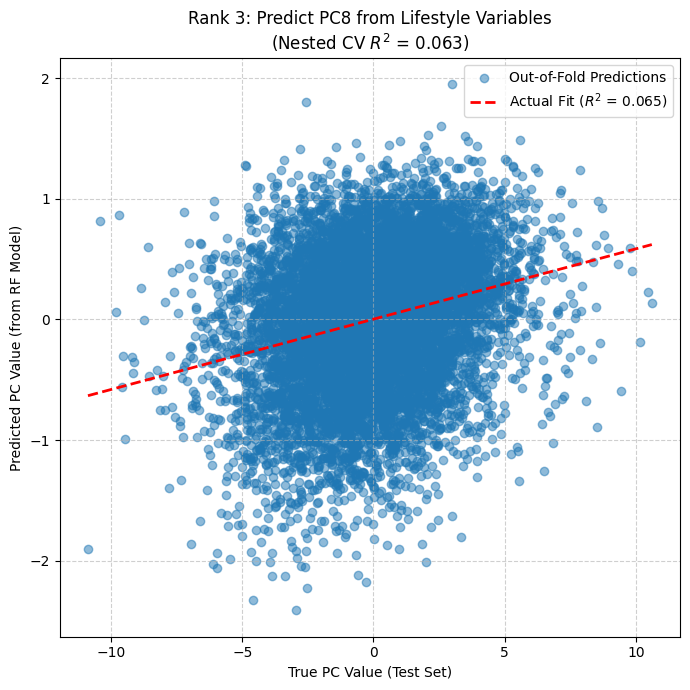

Prediction scatter plot for rank 4 (PC9) saved to './hongrui_result/RF_on_PCA_Results/top4_prediction_scatter_actual_fit_PC9.pdf'


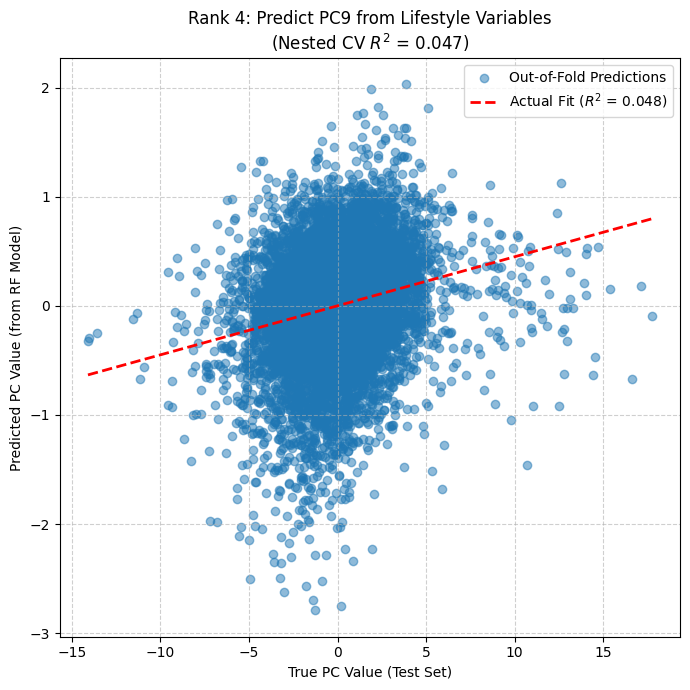

Prediction scatter plot for rank 5 (PC25) saved to './hongrui_result/RF_on_PCA_Results/top5_prediction_scatter_actual_fit_PC25.pdf'


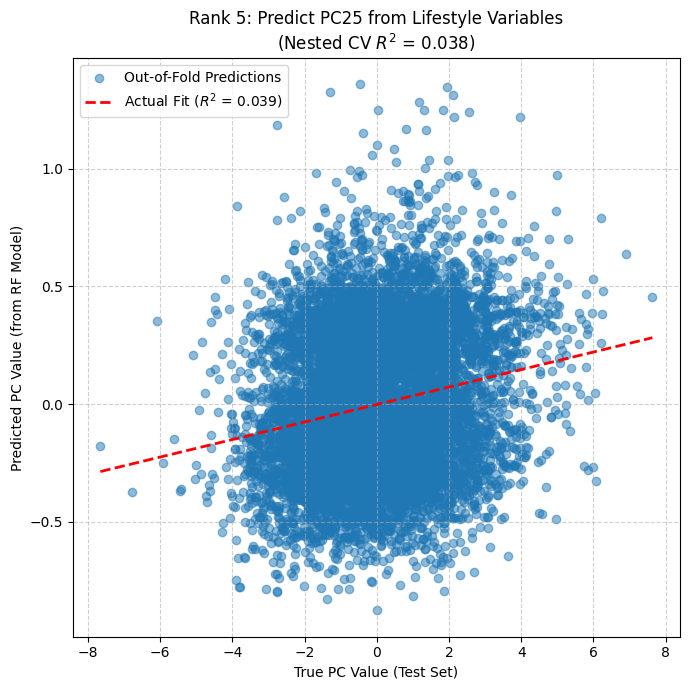


Analysis complete.

--- 8. Training FINAL (deployment) PCA + RF models on ALL AGP and saving ---


Final PCA explained variance ratio:


  Saved FINAL PC1: best CV R2=0.1361 | best_params={'rf__max_depth': None, 'rf__max_features': 'sqrt', 'rf__min_samples_leaf': 5, 'rf__n_estimators': 200}


  Saved FINAL PC2: best CV R2=0.0364 | best_params={'rf__max_depth': 20, 'rf__max_features': 'sqrt', 'rf__min_samples_leaf': 5, 'rf__n_estimators': 300}


  Saved FINAL PC3: best CV R2=0.1149 | best_params={'rf__max_depth': 20, 'rf__max_features': 'sqrt', 'rf__min_samples_leaf': 5, 'rf__n_estimators': 300}


...

  Saved FINAL PC9: best CV R2=0.0467 | best_params={'rf__max_depth': None, 'rf__max_features': 'log2', 'rf__min_samples_leaf': 10, 'rf__n_estimators': 300}


  Saved FINAL PC10: best CV R2=0.0341 | best_params={'rf__max_depth': 10, 'rf__max_features': 'sqrt', 'rf__min_samples_leaf': 5, 'rf__n_estimators': 300}


Final deployment objects saved under: ./RF_PCA_Trained_Models/
Files written:
 - final_otu_scaler.pkl
 - final_pca.pkl
 - final_rf_models.pkl
 - final_training_metadata.json

--- 9. Generating Feature Importance Plots (Top 5 PCs) ---
Saved feature importance plot for PC1 to './hongrui_result/RF_on_PCA_Results/Feature_Importances/feature_importance_PC1.pdf'
  -> Top drivers for PC1: bmi, weight_kg, fruit_frequency


Saved feature importance plot for PC2 to './hongrui_result/RF_on_PCA_Results/Feature_Importances/feature_importance_PC2.pdf'
  -> Top drivers for PC2: bmi, weight_kg, flossing_frequency
Saved feature importance plot for PC3 to './hongrui_result/RF_on_PCA_Results/Feature_Importances/feature_importance_PC3.pdf'
  -> Top drivers for PC3: bmi, weight_kg, sex


Saved feature importance plot for PC4 to './hongrui_result/RF_on_PCA_Results/Feature_Importances/feature_importance_PC4.pdf'
  -> Top drivers for PC4: bmi, weight_kg, bowel_movement_frequency
Saved feature importance plot for PC5 to './hongrui_result/RF_on_PCA_Results/Feature_Importances/feature_importance_PC5.pdf'
  -> Top drivers for PC5: bmi, weight_kg, fruit_frequency

All feature importance plots generated.


In [11]:
# 6b. Performance Bar Plot with Error Bars (top 15 only; cosmetics unchanged)
print("\n--- 6b. Generating Model Performance Bar Plot (Top 15 PCs) ---")

# Sort PCs by mean R2 descending
sorted_pcs = sorted(
    nested_cv_results.keys(),
    key=lambda pc: nested_cv_results[pc]['avg_r2'],
    reverse=True
)

top_n_bar = min(15, len(sorted_pcs))
top_15_pcs = sorted_pcs[:top_n_bar]

r2_means = [nested_cv_results[pc]['avg_r2'] for pc in top_15_pcs]
r2_stds  = [nested_cv_results[pc]['std_r2'] for pc in top_15_pcs]

perf_df = pd.DataFrame({
    'PC': top_15_pcs,
    'R2': r2_means,
    'Error': r2_stds
})

plt.figure(figsize=(10, 6))
bars = plt.bar(perf_df['PC'], perf_df['R2'],
               yerr=perf_df['Error'],
               capsize=5,
               color='steelblue',
               edgecolor='black',
               alpha=0.8)

plt.axhline(0, color='black', linewidth=1)
plt.title(f'Prediction Accuracy (Nested CV $R^2$) for Top {top_n_bar} Best-Performing Microbiome PCs')
plt.xlabel('Target Principal Component')
plt.ylabel('Average $R^2$ Score (+/- SD across 10 Folds)')
plt.grid(axis='y', linestyle='--', alpha=0.5)

for bar, r2 in zip(bars, r2_means):
    y_pos = bar.get_height() + (0.01 if r2 >= 0 else -0.04)
    plt.text(bar.get_x() + bar.get_width()/2, y_pos,
             f'{r2:.3f}',
             ha='center', va='bottom' if r2 >= 0 else 'top',
             fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(output_dir, "rf_model_performance_bar_plot_top15.pdf"))
print(f"Performance bar plot saved to '{output_dir}rf_model_performance_bar_plot_top15.pdf'")
plt.show()
plt.close()


# 7. Plot for Top 5 Best Performing PCs (keep cosmetics as-is)
print("\n--- 7. Generating Plots for Top 5 Best PCs ---")

top_n_scatter = min(5, len(sorted_pcs))
top_5_pcs = sorted_pcs[:top_n_scatter]

for rank, best_pc_name in enumerate(top_5_pcs, start=1):
    best_pc_avg_r2 = nested_cv_results[best_pc_name]['avg_r2']
    true_values = nested_cv_results[best_pc_name]['y_true']
    pred_values = nested_cv_results[best_pc_name]['y_pred']

    true_values_reshaped = true_values.reshape(-1, 1)
    line_model = LinearRegression()
    line_model.fit(true_values_reshaped, pred_values)

    min_val = true_values.min()
    max_val = true_values.max()
    line_x = np.array([min_val, max_val]).reshape(-1, 1)
    line_y = line_model.predict(line_x)
    line_r2 = line_model.score(true_values_reshaped, pred_values)

    plt.figure(figsize=(7, 7))
    plt.scatter(true_values, pred_values, alpha=0.5, label="Out-of-Fold Predictions")
    plt.plot(line_x.flatten(), line_y, '--', color='red', lw=2,
             label=f"Actual Fit ($R^2$ = {line_r2:.3f})")

    plt.title(
        f'Rank {rank}: Predict {best_pc_name} from Lifestyle Variables\n'
        f'(Nested CV $R^2$ = {best_pc_avg_r2:.3f})'
    )
    plt.xlabel("True PC Value (Test Set)")
    plt.ylabel("Predicted PC Value (from RF Model)")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()

    save_path = os.path.join(
        output_dir,
        f"top{rank}_prediction_scatter_actual_fit_{best_pc_name}.pdf"
    )
    plt.savefig(save_path)
    print(f"Prediction scatter plot for rank {rank} ({best_pc_name}) saved to '{save_path}'")
    plt.show()
    plt.close()

print("\nAnalysis complete.")

# Saving "deployment" models
# 1) Imports for saving
# 2) After nested CV finishes, it trains FINAL models on ALL AGP
#    - Fits OTU scaler + PCA on ALL AGP (defines the PC space you'll use for UKB projection)
#    - Trains one RF model per PC with GridSearchCV on ALL AGP
# 3) Saves:
#    - final_otu_scaler.pkl
#    - final_pca.pkl
#    - final_rf_models.pkl (dict PC1..PCk -> fitted pipeline)
#    - final_training_metadata.json (X columns, OTUs kept, params, CV scores)

print("\n--- 8. Training FINAL (deployment) PCA + RF models on ALL AGP and saving ---")

# 8.1 Fit FINAL OTU scaler + PCA on ALL AGP OTU data
# (This is the PCA basis we will use to define PC1..PCk for deployment.)
final_otu_scaler = StandardScaler()
final_Y_scaled = final_otu_scaler.fit_transform(otu_df_log_transformed.values)

final_pca = PCA(n_components=n_pcs_to_implement, random_state=random_state_cv)
final_Y_pcs = final_pca.fit_transform(final_Y_scaled)  # shape: (n_samples, n_pcs_to_implement)

print("Final PCA explained variance ratio:")
#for i, v in enumerate(final_pca.explained_variance_ratio_, start=1):
#    print(f"  PC{i}: {v*100:.2f}%")

# 8.2 Train FINAL RF models (one per PC) on ALL AGP metadata with CV hyperparameter search
# (This is separate from nested CV evaluation. Here we want a final model for projection.)
final_cv = KFold(n_splits=inner_cv_splits, shuffle=True, random_state=random_state_cv)

final_rf_models = {}      # pc_name -> best_estimator_
final_rf_cv_info = {}     # pc_name -> best_params + best_cv_r2

for pc_idx in range(n_pcs_to_implement):
    pc_name = f"PC{pc_idx+1}"
    y_target_all = final_Y_pcs[:, pc_idx]

    final_grid_search = GridSearchCV(
        estimator=rf_pipe,          # uses your existing Pipeline(imputer -> rf)
        param_grid=param_grid,      # uses your existing hyperparameter grid
        cv=final_cv,                # reuse your inner_cv_splits for training-time selection
        scoring="r2",
        n_jobs=-1,
        verbose=0,
        refit=True
    )
    final_grid_search.fit(X_metadata, y_target_all)

    final_rf_models[pc_name] = final_grid_search.best_estimator_
    final_rf_cv_info[pc_name] = {
        "best_params": final_grid_search.best_params_,
        "best_cv_r2": float(final_grid_search.best_score_)
    }

    print(f"  Saved FINAL {pc_name}: best CV R2={final_grid_search.best_score_:.4f} | best_params={final_grid_search.best_params_}")

# 8.3 Save final objects to disk (for UKB projection script)
joblib.dump(final_otu_scaler, os.path.join(model_dir, "final_otu_scaler.pkl"))
joblib.dump(final_pca,        os.path.join(model_dir, "final_pca.pkl"))
joblib.dump(final_rf_models,  os.path.join(model_dir, "final_rf_models.pkl"))

# 8.4 Save metadata needed to ensure UKB uses identical feature set / OTU set
final_training_metadata = {
    "random_state_cv": random_state_cv,
    "abundance_threshold": abundance_threshold,
    "n_pcs_to_implement": n_pcs_to_implement,
    "n_pcs_to_explore": n_pcs_to_explore,
    "outer_cv_splits": outer_cv_splits,
    "inner_cv_splits": inner_cv_splits,
    "numeric_cols_used_as_X": list(X_metadata.columns),
    "excluded_metadata_cols": list(EXCLUDE_METADATA_COLS),
    "otus_kept_after_filter": list(otus_to_keep),
    "final_pca_explained_variance_ratio": final_pca.explained_variance_ratio_.tolist(),
    "final_rf_cv_info": final_rf_cv_info,
    "param_grid": param_grid,
}

with open(os.path.join(model_dir, "final_training_metadata.json"), "w") as f:
    json.dump(final_training_metadata, f, indent=2)

print(f"Final deployment objects saved under: {model_dir}")
print("Files written:")
print(" - final_otu_scaler.pkl")
print(" - final_pca.pkl")
print(" - final_rf_models.pkl")
print(" - final_training_metadata.json")

# --- 9. Generate Feature Importance Plots for Top 5 PCs ---
print("\n--- 9. Generating Feature Importance Plots (Top 5 PCs) ---")

# Ensure we have the feature names
feature_names = X_metadata.columns
n_top_features = 15 # Number of top features to show per PC

# Create a directory specifically for importance plots
importance_dir = os.path.join(output_dir, "Feature_Importances")
os.makedirs(importance_dir, exist_ok=True)

# Loop through the first 5 PCs (or fewer if n_pcs_to_implement < 5)
pcs_to_plot = min(5, n_pcs_to_implement)

for pc_idx in range(pcs_to_plot):
    pc_name = f"PC{pc_idx+1}"
    
    # Retrieve the trained pipeline for this PC
    model_pipeline = final_rf_models[pc_name]
    
    # Access the Random Forest step specifically
    # The step name is 'rf' as defined in your pipeline earlier
    rf_model = model_pipeline.named_steps['rf']
    
    # Get importances
    importances = rf_model.feature_importances_
    
    # Create a DataFrame for easy sorting and plotting
    imp_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    })
    
    # Sort by importance (descending) and take top N
    imp_df_sorted = imp_df.sort_values(by='Importance', ascending=False).head(n_top_features)
    
    # Plotting
    plt.figure(figsize=(10, 6))
    sns.barplot(
        data=imp_df_sorted,
        x='Importance',
        y='Feature',
        palette='viridis',
        hue='Feature',       # Added to suppress future warning
        legend=False         # Hide legend as y-axis labels serve that purpose
    )
    
    plt.title(f'Top {n_top_features} Lifestyle Predictors for {pc_name}')
    plt.xlabel('Gini Importance')
    plt.ylabel('Metadata Variable')
    plt.tight_layout()
    
    # Save plot
    save_path = os.path.join(importance_dir, f"feature_importance_{pc_name}.pdf")
    plt.savefig(save_path)
    plt.close()
    
    print(f"Saved feature importance plot for {pc_name} to '{save_path}'")

    # Optional: Print the top 3 drivers to terminal for quick check
    top_3 = imp_df_sorted['Feature'].head(3).tolist()
    print(f"  -> Top drivers for {pc_name}: {', '.join(top_3)}")

print("\nAll feature importance plots generated.")

In [12]:
import shap
import matplotlib
matplotlib.use("Agg")  # important on HPC / no-display nodes
from joblib import Parallel, delayed

shap_dir = Path(output_dir) / "SHAP"
shap_dir.mkdir(parents=True, exist_ok=True)

pcs_to_explain = [f"PC{i}" for i in range(1, 11)]  # PC1..PC10

# how many samples to use for SHAP
rng = np.random.default_rng(42)
n_shap = min(20000, X_metadata.shape[0])
idx = rng.choice(X_metadata.index.to_numpy(), size=n_shap, replace=False)
X_shap = X_metadata.loc[idx].copy()

def available_cpus():
    """Prefer CPU affinity if enforced; fall back to SLURM vars; else 1."""
    try:
        return len(os.sched_getaffinity(0))
    except Exception:
        for k in ("SLURM_CPUS_PER_TASK", "SLURM_CPUS_ON_NODE"):
            v = os.environ.get(k)
            if v and v.isdigit():
                return int(v)
        return 1

MAX_PC_JOBS = 10
PC_JOBS = min(len(pcs_to_explain), MAX_PC_JOBS, available_cpus())

def run_one_pc(pc_name: str):
    # Expect: final_rf_models[pc_name] is a Pipeline with steps: "imputer", "rf"
    pipe = final_rf_models[pc_name]
    imputer = pipe.named_steps["imputer"]
    rf = pipe.named_steps["rf"]

    try:
        rf.n_jobs = 1
    except Exception:
        pass

    # Impute using the fitted imputer from training
    X_imp = pd.DataFrame(
        imputer.transform(X_shap),
        columns=X_shap.columns,
        index=X_shap.index,
    )

    # Tree SHAP for RandomForestRegressor
    explainer = shap.TreeExplainer(rf)
    shap_vals = explainer.shap_values(X_imp)  # (n_samples, n_features) for regression

    # 1) Beeswarm
    plt.figure()
    shap.summary_plot(shap_vals, X_imp, show=False)
    plt.xlabel(f"SHAP value for {pc_name} prediction")
    plt.title(f"SHAP Values for {pc_name}", fontsize=14)
    plt.tight_layout()
    plt.savefig(
        shap_dir / f"{pc_name}_shap_summary_beeswarm.png",
        dpi=200,
        bbox_inches="tight"
    )
    plt.close()

    # 2) Bar (global importance = mean |SHAP|)
    plt.figure()
    shap.summary_plot(shap_vals, X_imp, plot_type="bar", show=False)
    plt.xlabel(f"Mean absolute SHAP value for {pc_name}")
    plt.title(f"Mean Absolute SHAP Values for {pc_name}", fontsize=14)
    plt.tight_layout()
    plt.savefig(
        shap_dir / f"{pc_name}_shap_summary_bar.png",
        dpi=200,
        bbox_inches="tight"
    )
    plt.close()

    # 3) Save table of top drivers
    mean_abs = np.mean(np.abs(shap_vals), axis=0)
    shap_rank = (
        pd.DataFrame({"feature": X_imp.columns, "mean_abs_shap": mean_abs})
        .sort_values("mean_abs_shap", ascending=False)
    )
    shap_rank.to_csv(shap_dir / f"{pc_name}_mean_abs_shap.csv", index=False)

    return pc_name

print(f"[SHAP] Running {len(pcs_to_explain)} PCs with PC_JOBS={PC_JOBS}, n_shap={n_shap}, n_features={X_metadata.shape[1]}")
done = Parallel(n_jobs=PC_JOBS, backend="loky", verbose=10)(
    delayed(run_one_pc)(pc) for pc in pcs_to_explain
)
print(f"[SHAP] Done: {done}. Outputs in: {shap_dir}")

[SHAP] Running 10 PCs with PC_JOBS=10, n_shap=9559, n_features=27


[Parallel(n_jobs=10)]: Using backend LokyBackend with 10 concurrent workers.


[Parallel(n_jobs=10)]: Done   3 out of  10 | elapsed:  2.3min remaining:  5.3min


[Parallel(n_jobs=10)]: Done   5 out of  10 | elapsed:  3.5min remaining:  3.5min


[Parallel(n_jobs=10)]: Done   7 out of  10 | elapsed:  7.9min remaining:  3.4min


[SHAP] Done: ['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7', 'PC8', 'PC9', 'PC10']. Outputs in: hongrui_result/RF_on_PCA_Results/SHAP


[Parallel(n_jobs=10)]: Done  10 out of  10 | elapsed: 11.0min finished
